EDA ON TITANIC DATASET IN PYTHON


In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

DATA


In [79]:
train = pd.read_csv('train.csv')

In [80]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


EDA

MISSING DATA

In [81]:
train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

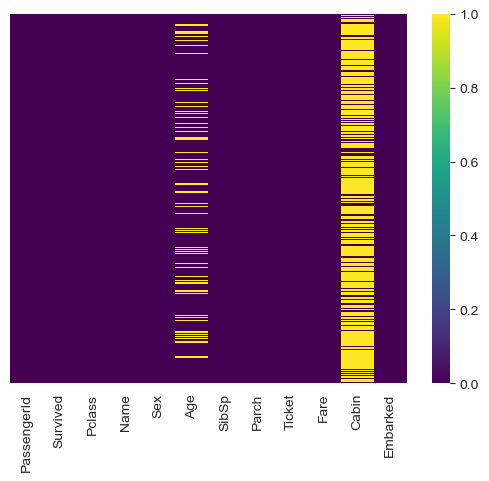

In [82]:
sns.heatmap(train.isnull(), yticklabels=False, cmap= 'viridis')

<Axes: xlabel='Survived', ylabel='count'>

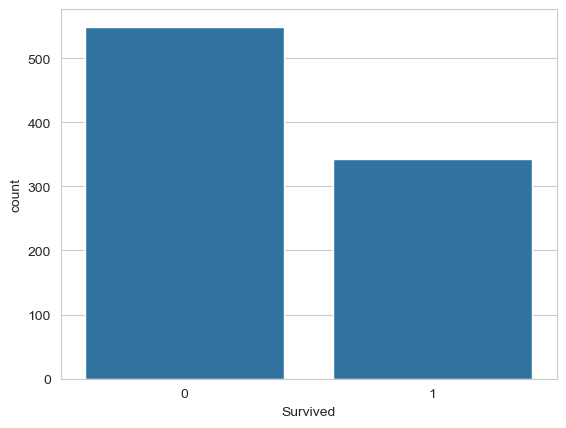

In [83]:
sns.set_style('whitegrid')
sns.countplot(x= 'Survived', data = train)


<Axes: xlabel='Survived', ylabel='count'>

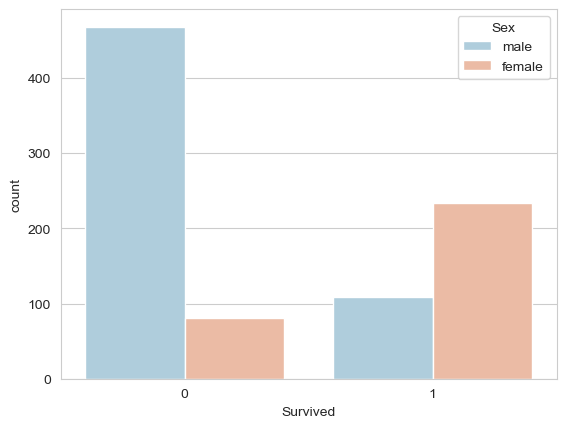

In [84]:
sns.set_style('whitegrid')
sns.countplot(x= 'Survived', hue= 'Sex', data= train,palette='RdBu_r')


<Axes: xlabel='Survived', ylabel='count'>

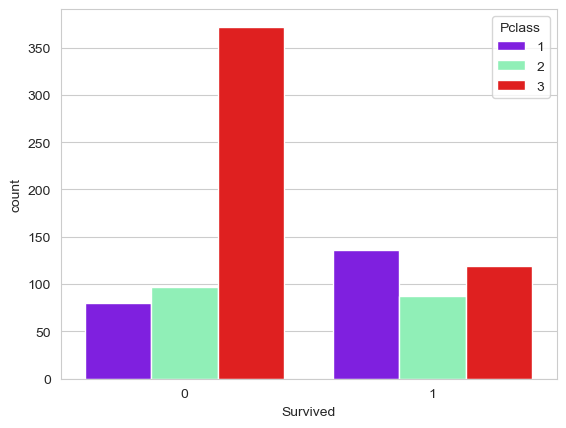

In [85]:
sns.set_style('whitegrid')
sns.countplot(x= 'Survived', hue = "Pclass", data= train,palette = 'rainbow')

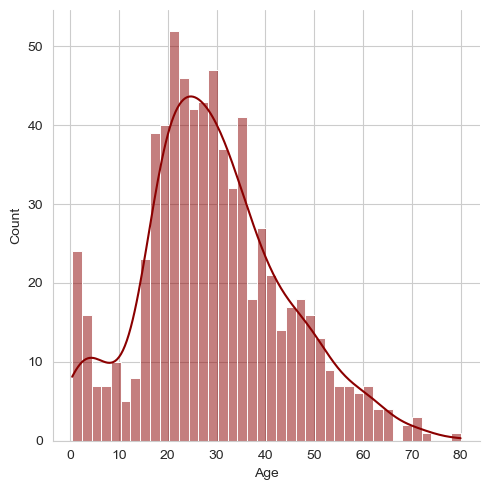

In [86]:
sns.displot(train['Age'].dropna(), kde = 'false', color = 'darkred', bins = 40)

<Axes: >

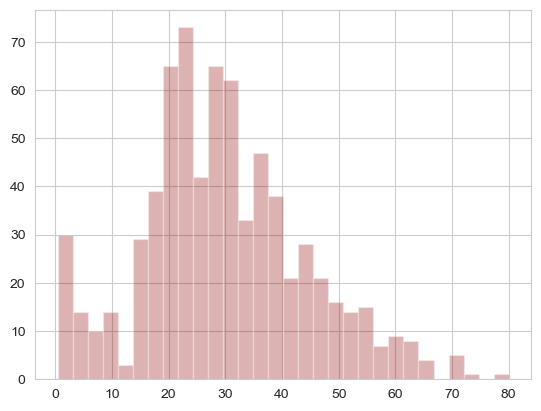

In [87]:
train['Age'].hist(bins = 30, color= 'darkred', alpha = 0.3)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22780\3861591364.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'SibSp', data = train, palette='viridis')


<Axes: xlabel='SibSp', ylabel='count'>

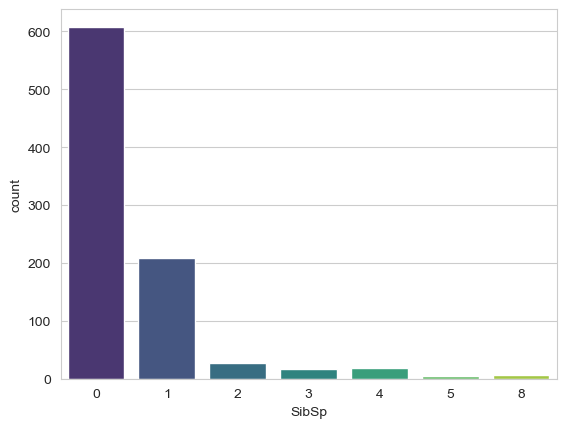

In [88]:
sns.countplot(x = 'SibSp', data = train, palette='viridis')

<Axes: xlabel='Fare', ylabel='Count'>

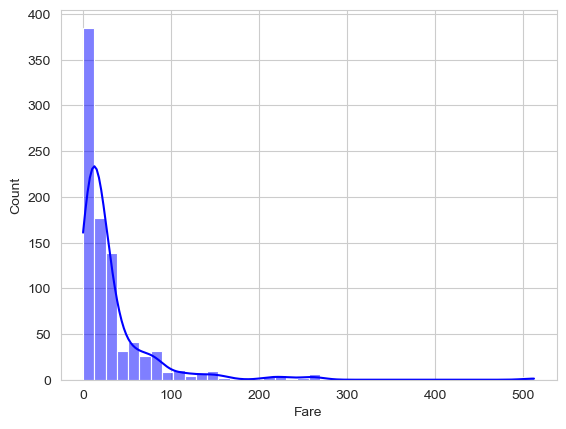

In [89]:
sns.histplot(train['Fare'], bins=40, kde=True, color='blue')

DATA CLEANING


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22780\2721556538.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= 'Pclass', y= 'Age', data=train,palette='winter')


<Axes: xlabel='Pclass', ylabel='Age'>

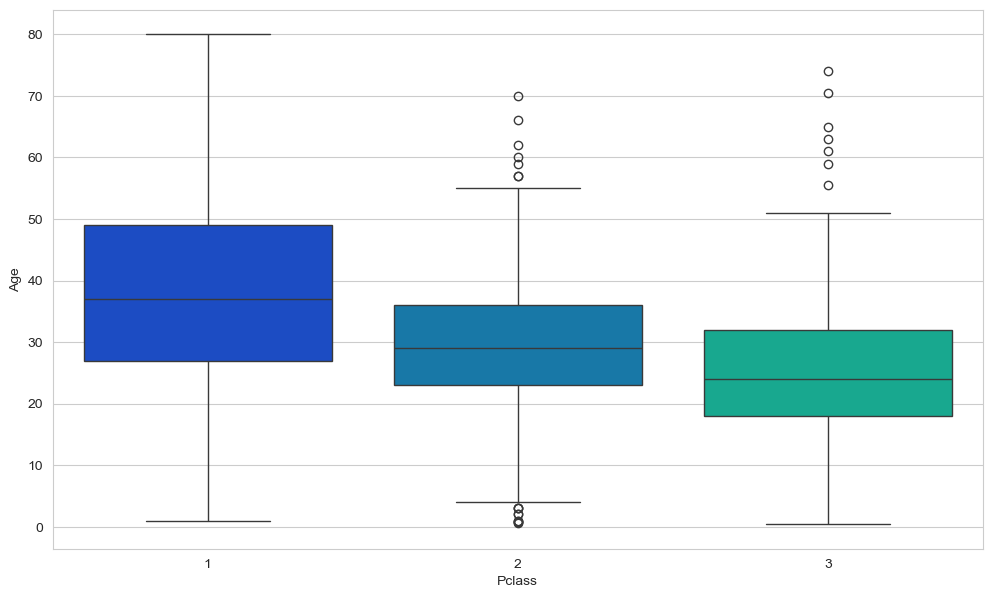

In [90]:
plt.figure(figsize=(12,7))
sns.boxplot(x= 'Pclass', y= 'Age', data=train,palette='winter')

In [91]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return 37
        
        elif Pclass == 2:
            return 29
        
        else:
            return 24
    else:

        return Age

In [92]:
train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis = 1)

<Axes: >

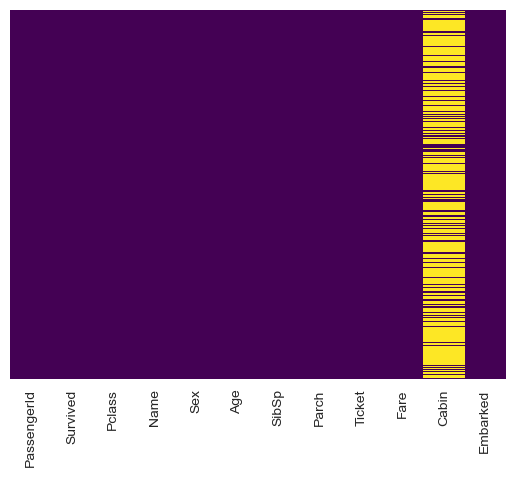

In [93]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [94]:
train.dropna(inplace=True)

DROPPING CABIN

In [95]:
train.drop('Cabin', axis = 1, inplace = True)

In [96]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,S


CONVERTING CATEGORICAL FEATURES

In [97]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 202 entries, 1 to 889
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  202 non-null    int64  
 1   Survived     202 non-null    int64  
 2   Pclass       202 non-null    int64  
 3   Name         202 non-null    object 
 4   Sex          202 non-null    object 
 5   Age          202 non-null    float64
 6   SibSp        202 non-null    int64  
 7   Parch        202 non-null    int64  
 8   Ticket       202 non-null    object 
 9   Fare         202 non-null    float64
 10  Embarked     202 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 18.9+ KB


In [101]:
pd.get_dummies(train['Embarked'],drop_first=True).head()

,Q,S
1,0,0
3,0,1
6,0,1
10,0,1
11,0,1


In [103]:
sex = pd.get_dummies(train['Sex'],drop_first=True)
embark = pd.get_dummies(train['Embarked'],drop_first=True)

In [105]:
train.drop(['Sex', 'Embarked', 'Name', 'Ticket'], axis = 1, inplace = True)

In [106]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
1,2,1,1,38.0,1,0,71.2833
3,4,1,1,35.0,1,0,53.1000
6,7,0,1,54.0,0,0,51.8625
10,11,1,3,4.0,1,1,16.7000
11,12,1,1,58.0,0,0,26.5500


In [107]:
train = pd.concat([train,sex,embark],axis = 1)

In [108]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
1,2,1,1,38.0,1,0,71.2833,0,0,0
3,4,1,1,35.0,1,0,53.1000,0,0,1
6,7,0,1,54.0,0,0,51.8625,1,0,1
10,11,1,3,4.0,1,1,16.7000,0,0,1
11,12,1,1,58.0,0,0,26.5500,0,0,1
